# ML-02 — Research Question and Provisional Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

I selected the **Content Refresh Prediction** lane.

My goal is to identify website pages that are likely to lose search performance so they can be refreshed before significant traffic declines. I chose this lane because it combines exploratory data analysis, feature engineering, SQL, and machine learning to support practical decision-making. It also aligns with my long-term goal of becoming a Data Scientist working on predictive analytics and recommendation systems.

## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

# 2. The Question

### Decision
Which website pages should be prioritized for content updates?

### Action
SEO analysts or content managers can refresh the highest-risk pages before their search performance declines.

### Unit of Analysis
Each individual content page.

### Output
A ranked list of pages with the highest probability of declining search performance.

### Cost of a Wrong Recommendation

False Positive:
A healthy page may be refreshed unnecessarily, increasing time and resource costs.

False Negative:
A declining page may not be updated, leading to lower search traffic, fewer clicks, and reduced visibility.

### Why Machine Learning?

Relationships between impressions, CTR, content age, ranking position, and user engagement are difficult to capture using simple rules. Machine learning can identify useful predictive patterns that help prioritize pages more effectively.

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
sh = df.shape
print(f"DataFrame shape: {sh}")

DataFrame shape: (30000, 44)


In [4]:
print("Information about the DataFrame:\n", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [5]:
print("DataFrame description:")
df.describe().T

DataFrame description:


,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
users_90d,30000.0,35.937700,103.748185,1.0,2.0,7.00,27.00,4913.00


In [6]:
print("Columns in the DataFrame:\n", df.columns)

Columns in the DataFrame:
 Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')


In [7]:
print("data types of the DataFrame:\n", df.dtypes)

data types of the DataFrame:
 content_id                 object
client_id                  object
search_volume             float64
competition               float64
competition_level          object
cpc                       float64
content_type               object
main_intent                object
word_count                float64
char_count                float64
provider_used              object
model_used                 object
impressions_90d             int64
clicks_90d                  int64
pageviews_90d               int64
sessions_90d                int64
users_90d                   int64
engaged_sessions_90d        int64
ai_sessions_90d             int64
scroll_events_90d           int64
days_with_impressions       int64
days_with_sessions          int64
impressions_last_30d        int64
clicks_last_30d             int64
sessions_last_30d           int64
impressions_prev_30d        int64
clicks_prev_30d             int64
sessions_prev_30d           int64
content_age_days  

In [8]:
print("Number of missing values in each column:\n", df.isnull().sum())

Number of missing values in each column:
 content_id                    0
client_id                     0
search_volume              2468
competition                2468
competition_level          2610
cpc                        2468
content_type                  0
main_intent                2374
word_count                 7699
char_count                 7699
provider_used             21438
model_used                 5733
impressions_90d               0
clicks_90d                    0
pageviews_90d                 0
sessions_90d                  0
users_90d                     0
engaged_sessions_90d          0
ai_sessions_90d               0
scroll_events_90d             0
days_with_impressions         0
days_with_sessions            0
impressions_last_30d          0
clicks_last_30d               0
sessions_last_30d             0
impressions_prev_30d          0
clicks_prev_30d               0
sessions_prev_30d             0
content_age_days              0
age_tier                      

In [9]:
print("Duplicate rows in the DataFrame:\n", df.duplicated().sum())

Duplicate rows in the DataFrame:
 0


Average CTR by Content Type
 content_type
comparison article    0.131205
feedly article        2.791274
keyword article       0.344766
Name: ctr, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_30420\1560878041.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="content_type", y="ctr", data=df, ci=None)


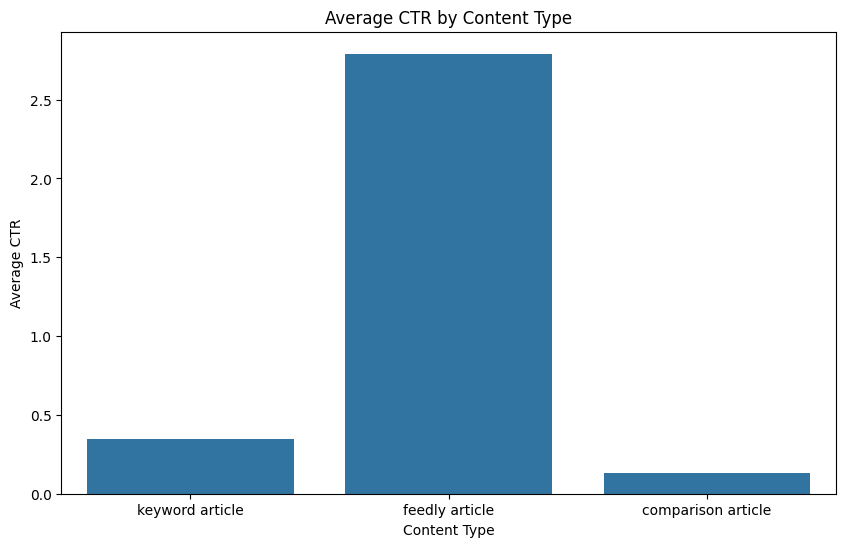

In [10]:
print("Average CTR by Content Type\n", df.groupby("content_type")["ctr"].mean())

plt.figure(figsize=(10, 6))
sns.barplot(x="content_type", y="ctr", data=df, ci=None)
plt.title("Average CTR by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average CTR")
plt.show()

Correlation between Average Position and CTR
               avg_position      ctr
avg_position       1.00000 -0.07259
ctr               -0.07259  1.00000


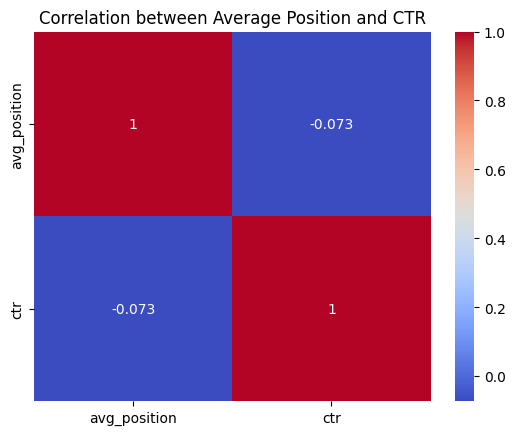

In [11]:
print("Correlation between Average Position and CTR\n", df[["avg_position","ctr"]].corr())

sns.heatmap(df[["avg_position","ctr"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Average Position and CTR")
plt.show()

In [12]:
declining = (df["trend_direction"]=="down").mean()*100
print(f"Percentage of Declining Pages: {declining:.2f}%")

Percentage of Declining Pages: 54.21%


# 3. Quick Look at the Data (2–3 Real Numbers)

* The starter dataset contains **30,000 content pages** with **44 features**, providing a solid foundation for exploratory data analysis and machine learning.

* The average Click-Through Rate (CTR) differs by content type:

  * **Feedly articles:** **2.79**
  * **Keyword articles:** **0.34**
  * **Comparison articles:** **0.13**
  * This suggests that **content type may influence user engagement**.

* The correlation between **average search position** and **CTR** is **-0.073**, indicating a **weak negative relationship**. Ranking position alone is unlikely to explain click-through performance.

* Approximately **54.21%** of the pages are labeled as **declining**, showing that content decline is common in the dataset and making it a meaningful prediction problem.

* These observations suggest that **combining multiple features with machine learning** may provide better decision support than relying on a single metric.

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

### What I **can** claim

* The analysis identifies **observed patterns and relationships** within the provided dataset.
* The machine learning model provides **decision support** by ranking pages that may be at risk of declining performance.
* The results are **directional** and can help content managers prioritize which pages to review or refresh.
* The findings are based on the available features and the data used in this project.

### What I **can't** claim

* This project **does not prove cause-and-effect relationships** between content features and search performance.
* The model **does not predict or explain Google's search algorithm**.
* The predictions are **not guaranteed** to be correct for every website or future situation.
* The results should be used as **evidence to support decisions**, not as absolute proof or certainty.


## Self-check

Before you submit, confirm each line honestly:

- ✔️ Every section above is filled — markdown thinking AND the code that backs it
- ✔️ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✔️ No client names, URLs, or private queries anywhere
- ✔️ My claims use careful words: observed, measured, directional, decision-support
- ✔️ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.✔️✔️